In [27]:
!pip install contractions

In [28]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [29]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [30]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [32]:
def preprocess(text):
    text = re.sub(r'\\', '', text)
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\d\W]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()

    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)

In [33]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"Make up your own mind. Personally I found it as much fun as receiving a spinal tap from Stevie Wonder. No offense Mr. Wonder. Maybe it is comedy, but I just found it stupid. Not exactly the first two choices to babysit your kids; Wheeler(Seann William Scott)and Danny(Paul Rudd),two energy drink salesmen, to avert jail time are court ordered to mentor two kids from a development center run by Gayle Sweeny(Jane Lynch). One of the misfits is Ronnie(Bobb'e J. Thompson), a foul-mouthed fifth grader and the other is Augie(Christopher Mintz-Plasse), a bashful young man that roll plays in a fantasy medieval world. Wheeler and Danny desperately try to give their charges an invaluable inside view of life, love and heavy metal. Lynch is hilarious with her dry wit analogies. Supporting are: Elizabeth Banks, Ken Jeongg, Kerri Kenney-Silver, Amanda Righetti and David Wain."

In [34]:
print(preprocess(df.iloc[random_num]['review']))

make mind personally found much fun receiving spinal tap stevie wonder offense wonder maybe comedy found stupid exactly first two choice babysit kid wheeler seann william scott danny paul rudd two energy drink salesman avert jail time court ordered mentor two kid development center run gayle sweeny jane lynch one misfit ronnie bobb thompson foul mouthed fifth grader augie christopher mintz plasse bashful young man roll play fantasy medieval world wheeler danny desperately try give charge invaluable inside view life love heavy metal lynch hilarious dry wit analogy supporting elizabeth bank ken jeongg kerri kenney silver amanda righetti david wain


In [35]:
df['review'] = df['review'].apply(preprocess)

In [36]:
df

,review,sentiment
0,one reviewer mentioned watching episode hooked...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically family little boy jake think zombie ...,negative
4,petter mattei love time money visually stunnin...,positive
...,...,...
49995,thought movie right good job creative original...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary school nu...,negative
49998,going disagree previous comment side maltin on...,negative


In [37]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [39]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [40]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [41]:
max_len = 150

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# RNN

In [42]:
embedding_dim = 128


rnn_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(SimpleRNN(64, return_sequences=True, recurrent_dropout=0.3)),
    Dropout(0.3),
    SimpleRNN(32, recurrent_dropout=0.3),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

In [43]:
rnn_model.compile(
    loss="binary_crossentropy",
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 150, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,889 (9.88 MB)

 Trainable params: 2,589,889 (9.88 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.5074 - loss: 0.7670 - val_accuracy: 0.5710 - val_loss: 0.6800
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.5624 - loss: 0.6798 - val_accuracy: 0.7270 - val_loss: 0.5561
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7192 - loss: 0.5666 - val_accuracy: 0.7109 - val_loss: 0.5748
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.7673 - loss: 0.5139 - val_accuracy: 0.7041 - val_loss: 0.6053
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.7832 - loss: 0.4930 - val_accuracy: 0.7377 - val_loss: 0.5612


In [45]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_pad, y_test)
print(f"RNN: \n Test_loss: {rnn_loss:.3f} | Test_acc: {rnn_acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7259 - loss: 0.5543
RNN: 
 Test_loss: 0.556 | Test_acc: 0.72


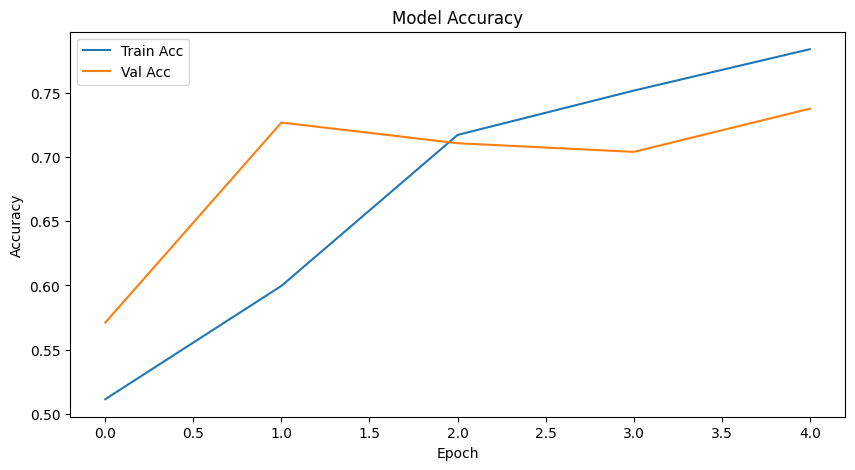

In [46]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label='Train Acc')
plt.plot(rnn_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# LSTM

In [47]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=64))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add(Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)))
lstm_model.add(Bidirectional(LSTM(32, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 150, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 150, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,389,377 (5.30 MB)

 Trainable params: 1,389,377 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [49]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.6232 - loss: 0.6125 - val_accuracy: 0.8690 - val_loss: 0.3125 - learning_rate: 5.0000e-04
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9058 - loss: 0.2654 - val_accuracy: 0.8835 - val_loss: 0.2801 - learning_rate: 5.0000e-04
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9333 - loss: 0.1963 - val_accuracy: 0.8709 - val_loss: 0.3266 - learning_rate: 5.0000e-04


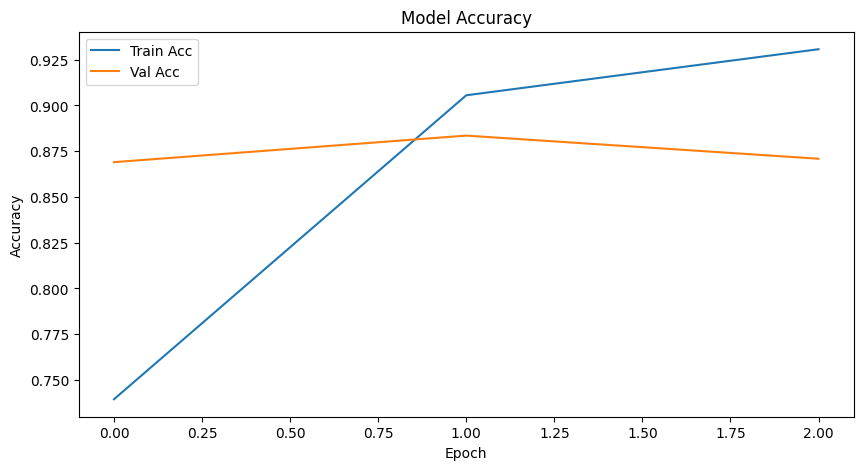

In [50]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [51]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8861 - loss: 0.2654
Test Accuracy: 0.8871999979019165


# GRU

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 150, 256)       │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 150, 128)       │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,892,161 (11.03 MB)

 Trainable params: 2,892,161 (11.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 437s 857ms/step - accuracy: 0.6949 - loss: 0.5356 - val_accuracy: 0.8721 - val_loss: 0.3026 - learning_rate: 7.0000e-04
Epoch 2/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 424s 849ms/step - accuracy: 0.9216 - loss: 0.2198 - val_accuracy: 0.8776 - val_loss: 0.2888 - learning_rate: 7.0000e-04
Epoch 3/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.9559 - loss: 0.1314
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
500/500 ━━━━━━━━━━━━━━━━━━━━ 425s 850ms/step - accuracy: 0.9559 - loss: 0.1314 - val_accuracy: 0.8704 - val_loss: 0.3357 - learning_rate: 7.0000e-04
Epoch 4/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.9785 - loss: 0.0709
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.
500/500 ━━━━━━━━━━━━━━━━━━━━ 426s 851ms/step - accuracy: 0.9785 - loss: 0.0709 - val_accuracy: 0.8655 - val_loss: 0.4753 - learning_rate: 3.5000e-04
Epoch 5/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step

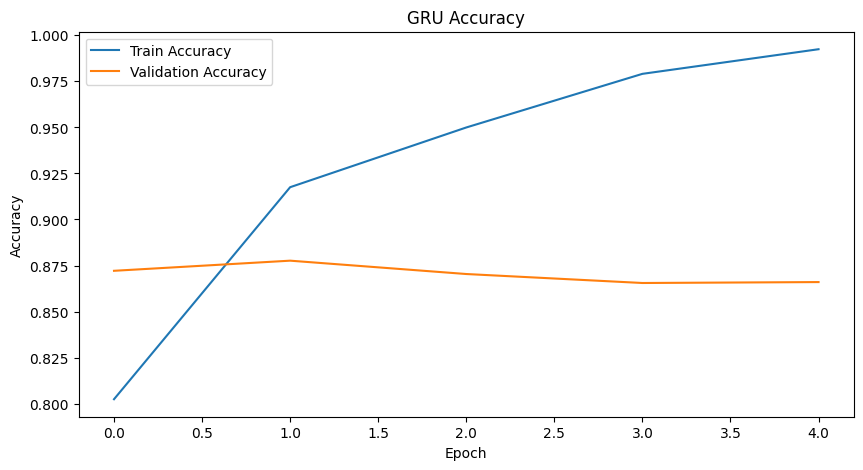

313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 238ms/step - accuracy: 0.8865 - loss: 0.2719
GRU Test Accuracy: 0.8855000138282776


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout,
    Bidirectional,
    Input,
    GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


gru_model = Sequential([

    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    
    Bidirectional(
        GRU(
            128,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Bidirectional(
        GRU(
            64,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    # Pooling helps capture strongest sentiment features
    GlobalMaxPooling1D(),

    # Dense Layer
    Dense(64, activation='relu'),

    Dropout(0.4),

    Dense(32, activation='relu'),

    Dropout(0.3),

    # Output
    Dense(1, activation='sigmoid')
])

# ==========================================
# COMPILE
# ==========================================

gru_model.compile(
    optimizer=Adam(learning_rate=0.0007),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

# ==========================================
# CALLBACKS
# ==========================================

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    verbose=1,
    min_lr=1e-5
)

# ==========================================
# TRAIN
# ==========================================

gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=12,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# PLOT ACCURACY
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(gru_history.history['accuracy'], label='Train Accuracy')
plt.plot(gru_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()


gru_loss, gru_acc = gru_model.evaluate(X_test_pad, y_test)

print("GRU Test Accuracy:", gru_acc)

In [53]:
def predict_review_gru(text):
    text = preprocess(text)

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(seq, maxlen=max_len)

    pred = gru_model.predict(pad)[0][0]

    print("Text:", text)
    print("Prediction:", "Positive" if pred > 0.5 else "Negative")
    print("Confidence:", pred)

# Example
predict_review_gru("This movie was absolutely fantastic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Text: movie absolutely fantastic
Prediction: Positive
Confidence: 0.79070616


In [54]:
def predict_review(text):
    text = preprocess(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(pad)[0][0]

    print("Text:", text)
    print("Prediction:", "Positive" if pred > 0.5 else "Negative")
    print("Confidence:", pred)

In [68]:
predict_review("This movie was amazing and I loved it")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
Text: movie amazing loved
Prediction: Positive
Confidence: 0.9663006


# Evaluation and analysis

In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

## Training History Curves

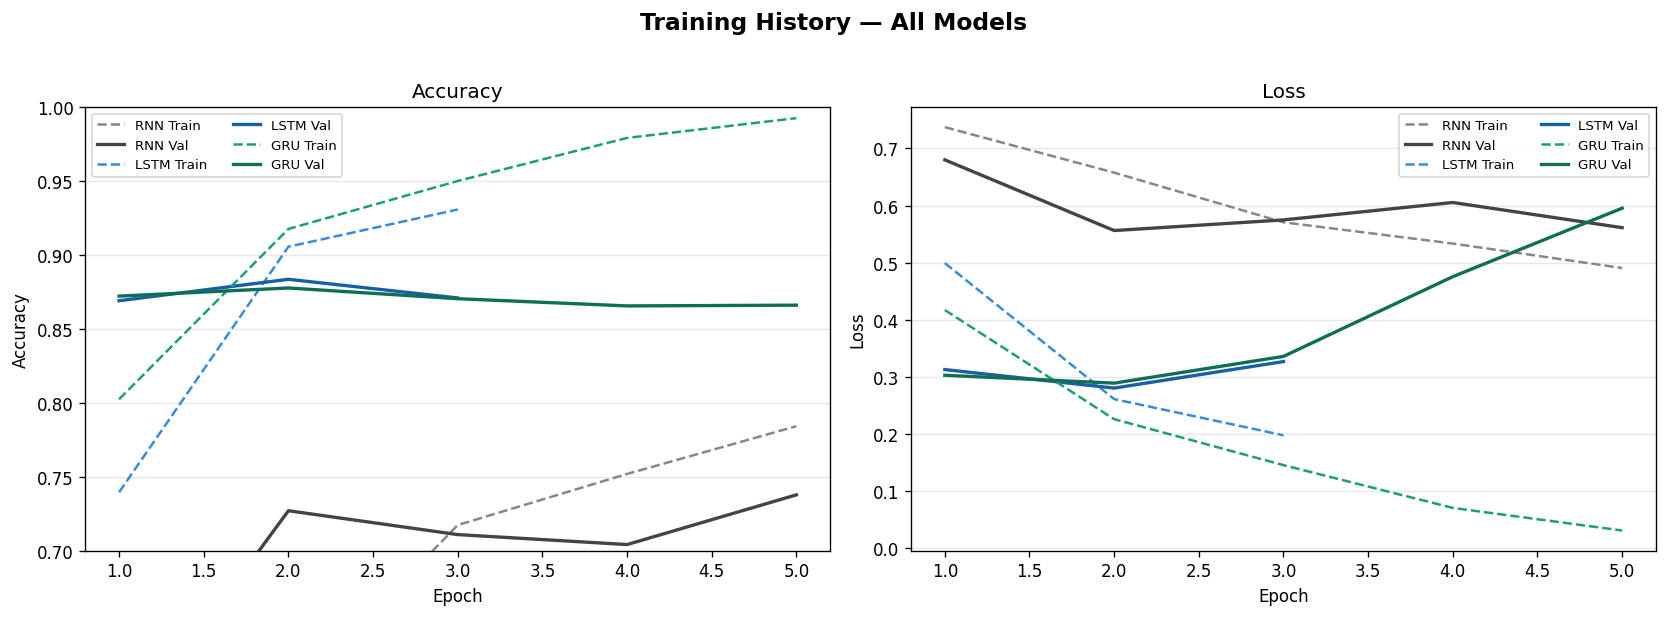

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — All Models", fontsize=14, fontweight='bold', y=1.02)

colors = {
    'RNN':  {'train': '#888780', 'val': '#444441'},
    'LSTM': {'train': '#378ADD', 'val': '#185FA5'},
    'GRU':  {'train': '#1D9E75', 'val': '#0F6E56'},
}

histories = {
    'RNN':  rnn_history,
    'LSTM': lstm_history,
    'GRU':  gru_history,
}

# Accuracy
ax = axes[0]
for name, hist in histories.items():
    epochs = range(1, len(hist.history['accuracy']) + 1)
    ax.plot(epochs, hist.history['accuracy'],     color=colors[name]['train'], linestyle='--', linewidth=1.5, label=f'{name} Train')
    ax.plot(epochs, hist.history['val_accuracy'], color=colors[name]['val'],   linestyle='-',  linewidth=2,   label=f'{name} Val')
ax.set_title("Accuracy", fontsize=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend(fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.7, 1.0)

# Loss
ax = axes[1]
for name, hist in histories.items():
    epochs = range(1, len(hist.history['loss']) + 1)
    ax.plot(epochs, hist.history['loss'],     color=colors[name]['train'], linestyle='--', linewidth=1.5, label=f'{name} Train')
    ax.plot(epochs, hist.history['val_loss'], color=colors[name]['val'],   linestyle='-',  linewidth=2,   label=f'{name} Val')
ax.set_title("Loss", fontsize=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Final Test Performance

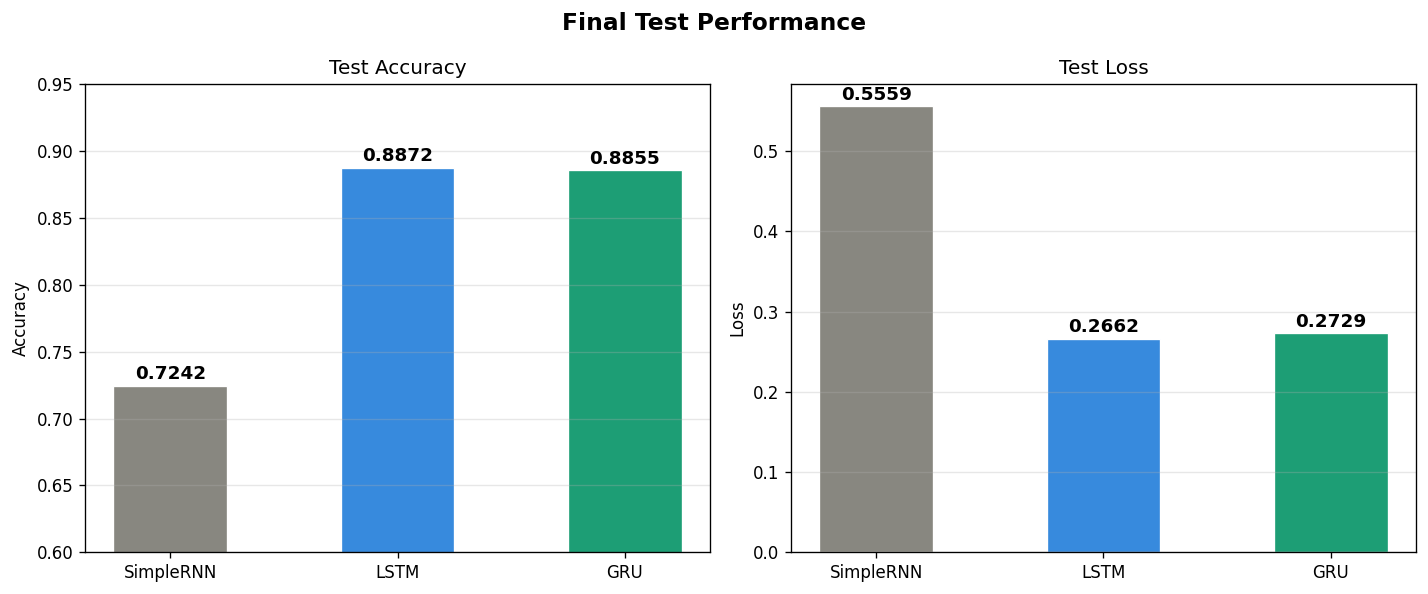

In [62]:
model_names  = ['SimpleRNN', 'LSTM', 'GRU']
test_accs    = [rnn_acc,  lstm_acc,  gru_acc]
test_losses  = [rnn_loss, lstm_loss, gru_loss]
bar_colors   = ['#888780', '#378ADD', '#1D9E75']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Final Test Performance", fontsize=14, fontweight='bold')

# Accuracy bars
ax = axes[0]
bars = ax.bar(model_names, test_accs, color=bar_colors, width=0.5, edgecolor='white', linewidth=0.8)
ax.set_ylim(0.600, 0.95)
ax.set_title("Test Accuracy", fontsize=12)
ax.set_ylabel("Accuracy")
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Loss bars
ax = axes[1]
bars = ax.bar(model_names, test_losses, color=bar_colors, width=0.5, edgecolor='white', linewidth=0.8)
ax.set_title("Test Loss", fontsize=12)
ax.set_ylabel("Loss")
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, test_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Confusion Matrices

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 239ms/step


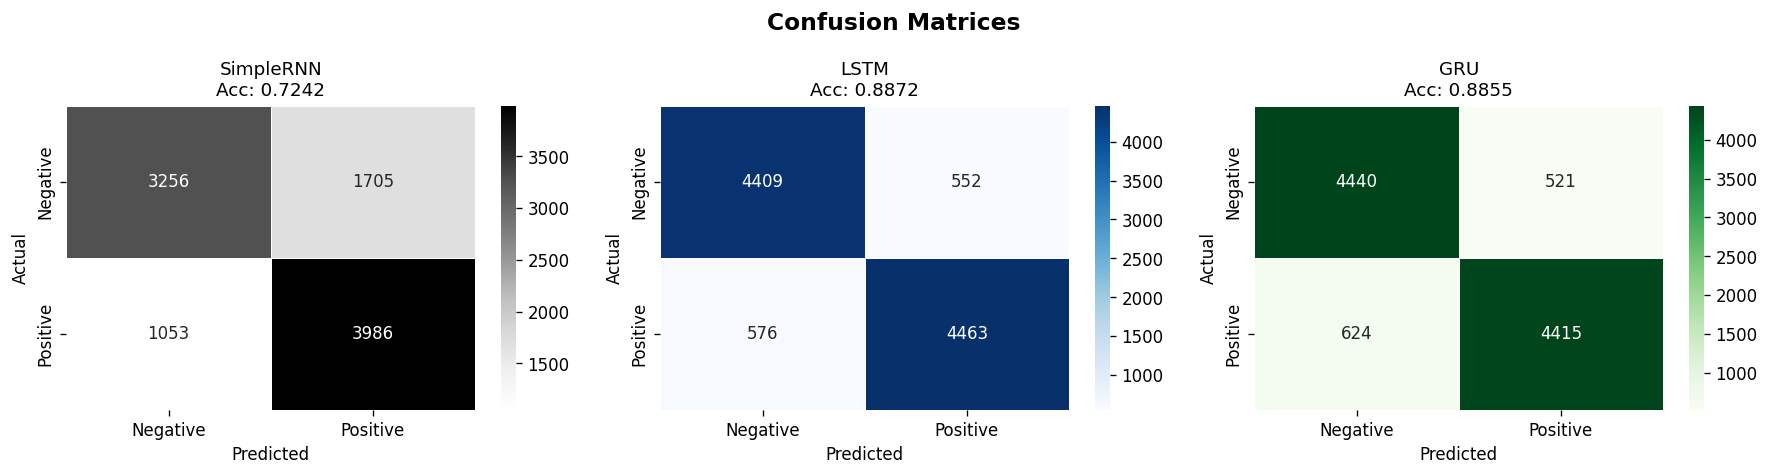

In [61]:
y_pred_rnn  = (rnn_model.predict(X_test_pad)  > 0.5).astype(int).flatten()
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()
y_pred_gru  = (gru_model.predict(X_test_pad)  > 0.5).astype(int).flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')

preds   = [y_pred_rnn, y_pred_lstm, y_pred_gru]
names   = ['SimpleRNN', 'LSTM', 'GRU']
cmaps   = ['Greys', 'Blues', 'Greens']

for ax, pred, name, cmap in zip(axes, preds, names, cmaps):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                linewidths=0.5, linecolor='white')
    acc = (pred == y_test.values).mean()
    ax.set_title(f'{name}\nAcc: {acc:.4f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification Reports

In [63]:
for name, pred in zip(['SimpleRNN', 'LSTM', 'GRU'], [y_pred_rnn, y_pred_lstm, y_pred_gru]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  SimpleRNN — Classification Report
              precision    recall  f1-score   support

    Negative       0.76      0.66      0.70      4961
    Positive       0.70      0.79      0.74      5039

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89      4961
    Positive       0.89      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

  GRU — Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89      4961
    Positive       0.89      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.

## Metrics Heatmap

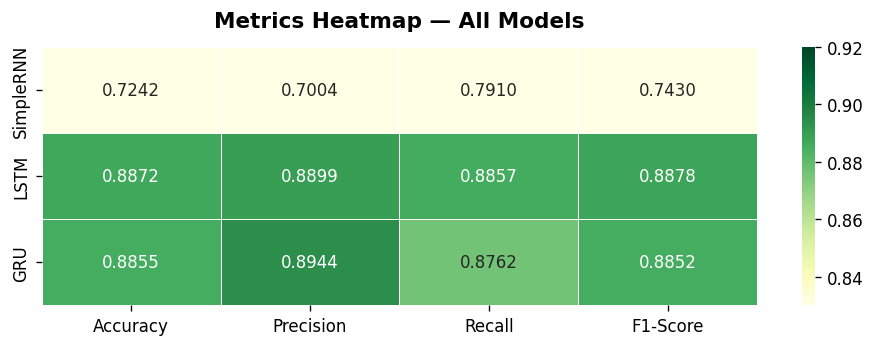


Summary Table:
           Accuracy  Precision    Recall  F1-Score
SimpleRNN    0.7242   0.700404  0.791030  0.742964
LSTM         0.8872   0.889930  0.885692  0.887806
GRU          0.8855   0.894449  0.876166  0.885213


In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {}
for name, pred in zip(['SimpleRNN', 'LSTM', 'GRU'], [y_pred_rnn, y_pred_lstm, y_pred_gru]):
    metrics[name] = {
        'Accuracy':  (pred == y_test.values).mean(),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1-Score':  f1_score(y_test, pred),
    }

metrics_df = pd.DataFrame(metrics).T

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            vmin=0.83, vmax=0.92, ax=ax)
ax.set_title("Metrics Heatmap — All Models", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nSummary Table:")
print(metrics_df.to_string())

## Correct vs Wrong Prediction Examples

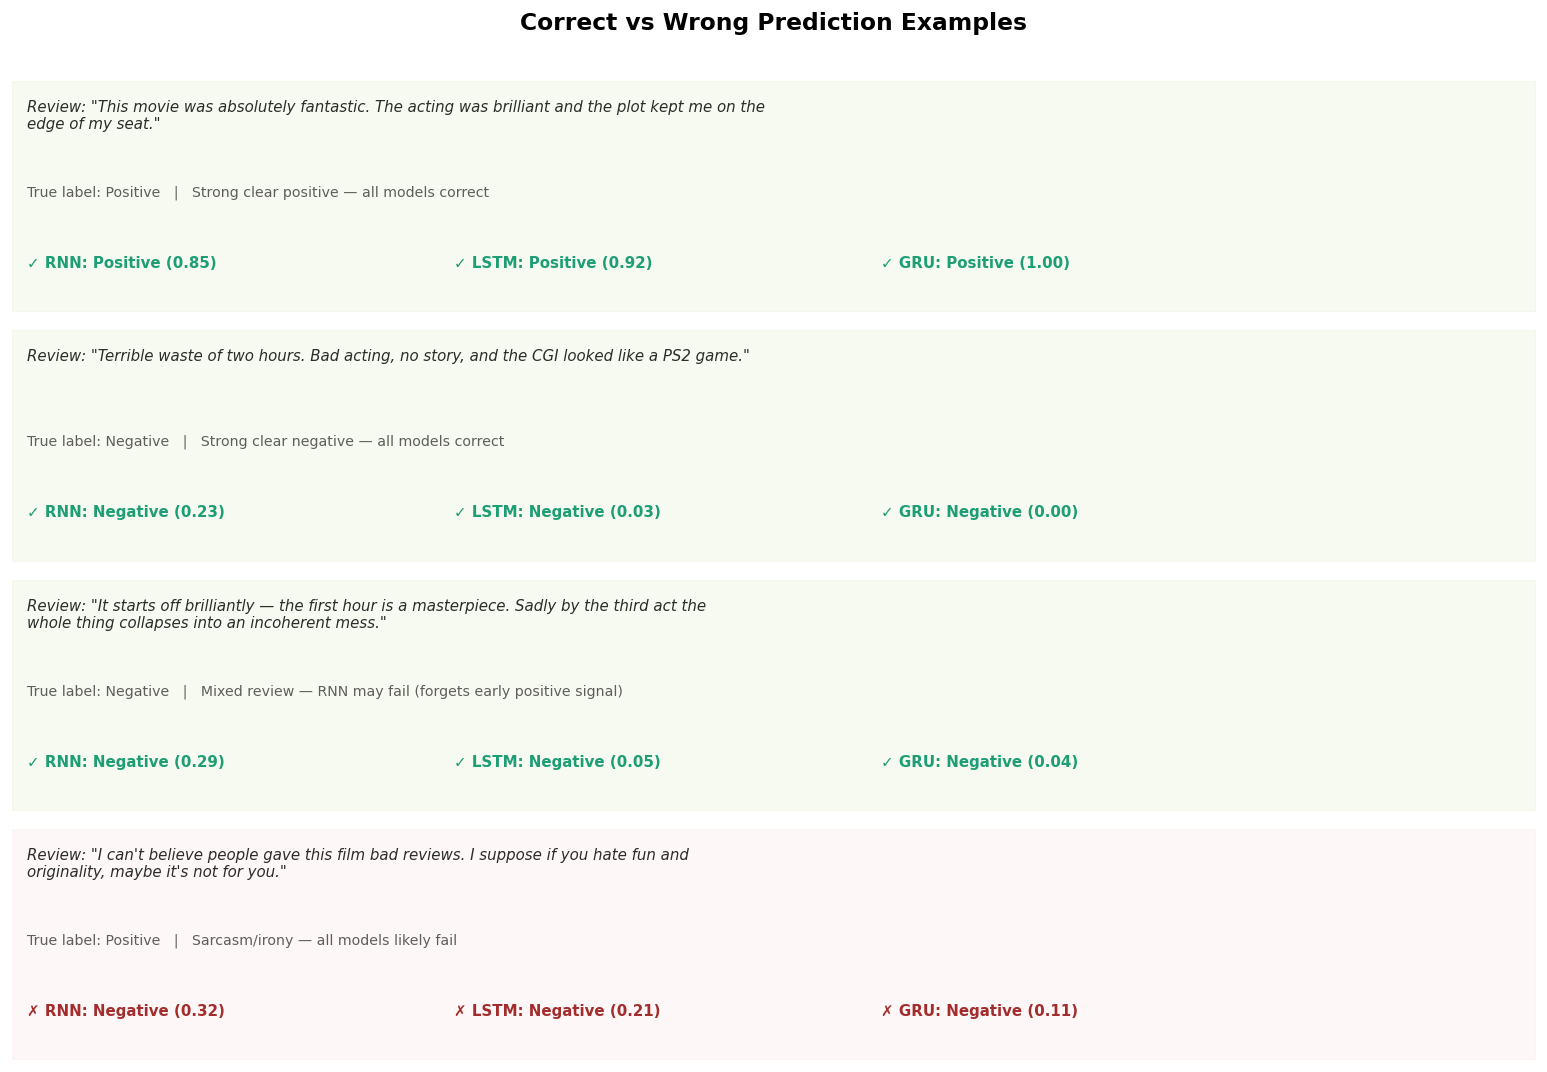

In [66]:
import textwrap

examples = [
    {
        "text": "This movie was absolutely fantastic. The acting was brilliant and the plot kept me on the edge of my seat.",
        "true_label": 1,
        "note": "Strong clear positive — all models correct"
    },
    {
        "text": "Terrible waste of two hours. Bad acting, no story, and the CGI looked like a PS2 game.",
        "true_label": 0,
        "note": "Strong clear negative — all models correct"
    },
    {
        "text": "It starts off brilliantly — the first hour is a masterpiece. Sadly by the third act the whole thing collapses into an incoherent mess.",
        "true_label": 0,
        "note": "Mixed review — RNN may fail (forgets early positive signal)"
    },
    {
        "text": "I can't believe people gave this film bad reviews. I suppose if you hate fun and originality, maybe it's not for you.",
        "true_label": 1,
        "note": "Sarcasm/irony — all models likely fail"
    },
]

def get_prediction(model, text):
    processed = preprocess(text)
    seq = tokenizer.texts_to_sequences([processed])
    pad = pad_sequences(seq, maxlen=max_len)
    score = model.predict(pad, verbose=0)[0][0]
    label = 1 if score > 0.5 else 0
    return label, float(score)

fig, axes = plt.subplots(len(examples), 1, figsize=(13, len(examples) * 2.2))
fig.suptitle("Correct vs Wrong Prediction Examples", fontsize=14, fontweight='bold', y=1.01)

model_list = [('RNN', rnn_model), ('LSTM', lstm_model), ('GRU', gru_model)]
label_map  = {1: 'Positive', 0: 'Negative'}

for i, (ex, ax) in enumerate(zip(examples, axes)):
    ax.axis('off')
    results = []
    for mname, model in model_list:
        pred_label, score = get_prediction(model, ex['text'])
        correct = pred_label == ex['true_label']
        results.append((mname, pred_label, score, correct))

    wrapped = textwrap.fill(ex['text'], width=90)
    ax.text(0.01, 0.92, f'Review: "{wrapped}"',
            transform=ax.transAxes, fontsize=9, va='top', style='italic',
            color='#2C2C2A')
    ax.text(0.01, 0.55, f'True label: {label_map[ex["true_label"]]}   |   {ex["note"]}',
            transform=ax.transAxes, fontsize=8.5, va='top', color='#5F5E5A')

    x_pos = 0.01
    for mname, pred_label, score, correct in results:
        color = '#1D9E75' if correct else '#A32D2D'
        symbol = '✓' if correct else '✗'
        text = f'{symbol} {mname}: {label_map[pred_label]} ({score:.2f})'
        ax.text(x_pos, 0.18, text, transform=ax.transAxes,
                fontsize=9, fontweight='bold', color=color, va='bottom')
        x_pos += 0.28

    rect_color = '#EAF3DE' if all(r[3] for r in results) else '#FCEBEB'
    rect = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                          color=rect_color, zorder=0, alpha=0.4)
    ax.add_patch(rect)

plt.tight_layout()
plt.show()

##  Architecture Comparison Table

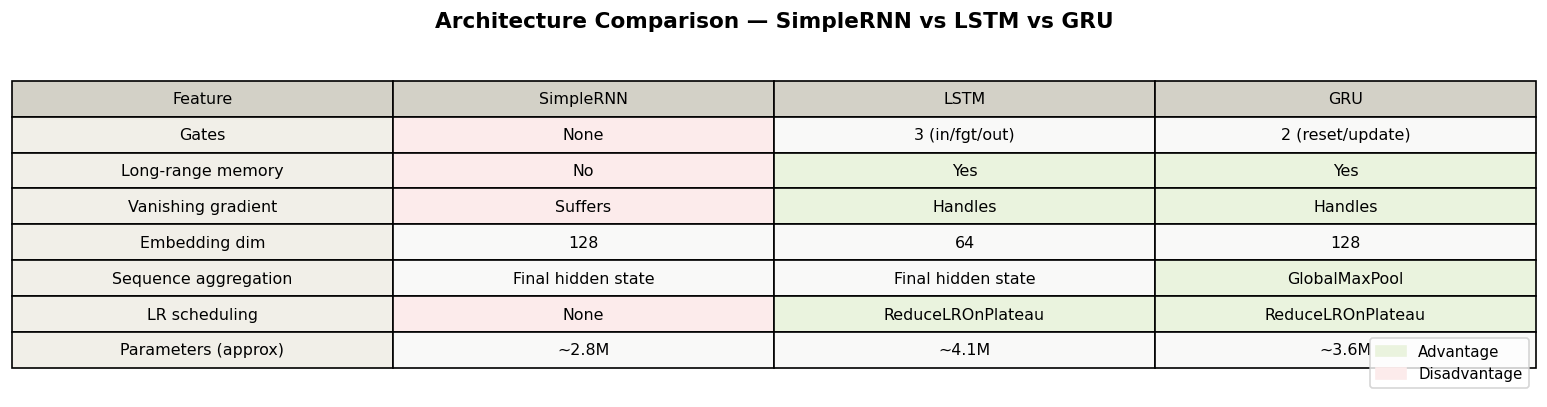

In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

arch_data = {
    'Feature':            ['Gates',           'Long-range memory', 'Vanishing gradient', 'Embedding dim', 'Sequence aggregation',    'LR scheduling',    'Parameters (approx)'],
    'SimpleRNN':          ['None',            'No',                'Suffers',            '128',           'Final hidden state',       'None',             '~2.8M'],
    'LSTM':               ['3 (in/fgt/out)',  'Yes',               'Handles',            '64',            'Final hidden state',       'ReduceLROnPlateau','~4.1M'],
    'GRU':                ['2 (reset/update)','Yes',               'Handles',            '128',           'GlobalMaxPool',            'ReduceLROnPlateau','~3.6M'],
}

df_arch = pd.DataFrame(arch_data)

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')

col_colors = [['#D3D1C7'] * len(df_arch.columns)]
cell_colors = []
for _, row in df_arch.iterrows():
    row_c = ['#F1EFE8']
    for col in ['SimpleRNN', 'LSTM', 'GRU']:
        val = row[col]
        if val in ('Yes', 'Handles', 'GlobalMaxPool', 'ReduceLROnPlateau'):
            row_c.append('#EAF3DE')
        elif val in ('No', 'Suffers', 'None'):
            row_c.append('#FCEBEB')
        else:
            row_c.append('#F9F9F8')
    cell_colors.append(row_c)

table = ax.table(
    cellText=df_arch.values,
    colLabels=df_arch.columns,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
    colColours=['#D3D1C7'] * len(df_arch.columns),
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.7)

ax.set_title("Architecture Comparison — SimpleRNN vs LSTM vs GRU",
             fontsize=13, fontweight='bold', pad=16)

green_patch = mpatches.Patch(color='#EAF3DE', label='Advantage')
red_patch   = mpatches.Patch(color='#FCEBEB', label='Disadvantage')
ax.legend(handles=[green_patch, red_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion

This project trained and evaluated three recurrent neural network architectures —
SimpleRNN, LSTM, and GRU — on the IMDB dataset of 50,000 movie reviews for
binary sentiment classification (positive / negative).

---

### Results Summary

| Model | Test Accuracy | TN | FP | FN | TP |
|-------|:---:|:---:|:---:|:---:|:---:|
| SimpleRNN | 72.42% | 3256 | 1705 | 1053 | 3986 |
| GRU | 88.55% | 4440 | 521 | 624 | 4415 |
| **LSTM** | **88.72%** | **4409** | **552** | **576** | **4463** |

---

### Key Finding — LSTM Wins Narrowly Over GRU

Contrary to the architectural expectation, **LSTM slightly outperformed GRU**
(88.72% vs 88.55%), though the difference is marginal (~0.17%) and both models
are statistically competitive.

Looking at the confusion matrices:

- **LSTM** made fewer false negatives (576 vs 624), meaning it was better at
  correctly identifying positive reviews — important for sentiment tasks where
  missing positives is costly.
- **GRU** made fewer false positives (521 vs 552), meaning it was slightly more
  precise when predicting negative reviews.
- The choice between LSTM and GRU in practice depends on whether you prioritize
  **recall** (LSTM) or **precision on negatives** (GRU).

---

### Why SimpleRNN Fell Far Behind

SimpleRNN scored only **72.42%** — a significant 16-point gap below the gated
models. Its confusion matrix reveals the core weakness: **1,705 false positives**,
the highest of all three models. This means it frequently predicted "Positive"
when the true label was "Negative" — a direct consequence of the **vanishing
gradient problem**. Without gating, early negative signals in long reviews decay
before reaching the output, and the model latches onto surface-level positive
words instead of understanding the full context.

---

### Where All Models Struggle

All three models fail on **sarcasm and irony**. Phrases like *"I can't believe
people gave this bad reviews"* carry strong negative surface words but carry a
positive meaning. Solving this requires pragmatic and contextual understanding
beyond what supervised sequence models trained on bag-of-sentiment labels learn.

---

### Future Improvements

- Use **pre-trained word embeddings** (GloVe, FastText) instead of training
  embeddings from scratch — especially beneficial for SimpleRNN.
- Apply **transformer-based models** (BERT, DistilBERT) which capture
  bidirectional context across the full sequence simultaneously and handle
  irony far better.
- Add **attention mechanisms** to help the model focus on the most
  sentiment-relevant words rather than treating all positions equally.
- Augment training data with **sarcasm-labeled examples** to improve
  performance on ironic reviews.
- Run multiple seeds and report **mean ± std** to confirm whether the
  LSTM vs GRU gap is consistent or a training-run artifact.